# Introduction

In [2]:
import pandas as pd
import numpy as np

Reading the dataset

In [4]:
df_cafe = pd.read_csv(r"C:\Users\champ\Downloads\archive\dirty_cafe_sales.csv")

Making a copy of the dataset

In [6]:
df_cafe_copy = df_cafe.copy()

Showing the first few rows of the data set

In [8]:
df_cafe.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


Number of rows and columns of df_cafe

In [10]:
df_cafe.shape

(10000, 8)

The number of non-null values in each column and their data types

In [12]:
df_cafe.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


The basic statistics

In [14]:
df_cafe.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


Original data types of each columns

In [16]:
df_cafe.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

Showing all the unique values of each column, number of unique values in the transaction date column.

In [18]:
u_items= df_cafe_copy["Item"].unique()
u_ppu = df_cafe["Price Per Unit"].unique()
u_quantity = df_cafe["Quantity"].unique()
u_tspent = df_cafe["Total Spent"].unique()
u_pm = df_cafe["Payment Method"].unique()
u_l = df_cafe["Location"].unique()
noud = df_cafe["Transaction Date"].nunique()

In [19]:
print("Unique Items:- ", u_items)
print(" ")
print("Unique Prices Per Unit:-", u_ppu)
print(" ")
print("Unique Quantities:- ", u_quantity)
print(" ")
print("Unique Total Spents:- ", u_tspent)
print(" ")
print("Unique Payment Methods:- ", u_pm)
print(" ")
print("Unique Locations:- ", u_l)
print(" ")
print("Number of unique dates:- ", noud)
print(" ")

Unique Items:-  ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
 
Unique Prices Per Unit:- ['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']
 
Unique Quantities:-  ['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
 
Unique Total Spents:-  ['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5']
 
Unique Payment Methods:-  ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
 
Unique Locations:-  ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
 
Number of unique dates:-  367
 


The percentage of null values in each column

In [21]:
percentage = (df_cafe.isnull().sum()/len(df_cafe))* 100
print("Percentages of the null values in every category")
print(percentage)

Percentages of the null values in every category
Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64


# Fixing Null values

Turning data types of columns that have numeric data. The string values turn into nan. 

In [24]:
df_cafe["Quantity"] = pd.to_numeric(df_cafe["Quantity"], errors='coerce')
df_cafe["Price Per Unit"] = pd.to_numeric(df_cafe["Price Per Unit"], errors='coerce')
df_cafe["Total Spent"] = pd.to_numeric(df_cafe["Total Spent"], errors='coerce')

Filtering all the rows that have items that are not nan, Unknown or error

In [26]:
Cof_filter = df_cafe["Item"] == "Coffee"
Ca_filter = df_cafe["Item"] == "Cake"
Coo_filter = df_cafe["Item"] == "Cookie"
sal_filter = df_cafe["Item"] == "Salad"
smo_filter = df_cafe["Item"] == "Smoothie"
san_filter = df_cafe["Item"] == "Sandwich"
jui_filter = df_cafe["Item"] == "Juice"
tea_filter = df_cafe["Item"] == "Tea"

Finding the avarage price of each item.

In [28]:
cof_avg = df_cafe[Cof_filter]["Price Per Unit"].mean()
ca_avg = df_cafe[Ca_filter]["Price Per Unit"].mean()
coo_avg = df_cafe[Coo_filter]["Price Per Unit"].mean()
sal_avg = df_cafe[sal_filter]["Price Per Unit"].mean()
smo_avg = df_cafe[smo_filter]["Price Per Unit"].mean()
san_avg = df_cafe[san_filter]["Price Per Unit"].mean()
jui_avg = df_cafe[jui_filter]["Price Per Unit"].mean()
tea_avg = df_cafe[tea_filter]["Price Per Unit"].mean()

Making a new dataset that has items and their Price Per Unit

In [30]:
df_item = pd.DataFrame({"Item": ["Coffee", "Cake", "Cookie", "Salad", "Smoothie", "Sandwich", "Juice", "Tea"],
             "Price Per Unit": [cof_avg, ca_avg, coo_avg, sal_avg, smo_avg, san_avg, jui_avg, tea_avg]})

Replacing null, unknow,  Error valus in the Item coulmn using the corresponding value in the Price Per Unit column.

In [32]:
error_values = ["ERROR", "UNKNOWN", np.nan]
mask = df_cafe["Item"].isin(error_values)
for x in df_cafe.index:
    for y in df_item.index:
        if df_cafe.loc[x, "Price Per Unit"] == df_item.loc[y, "Price Per Unit"]:
            df_cafe.loc[mask, 'Item'] = df_item.loc[y, 'Item']


Replacing null, unknow,  Error valus in the Price Per Unit column using the corresponding value in the Item column.

In [34]:
mask = df_cafe["Price Per Unit"].isin(error_values)
for x in df_cafe.index:
    for y in df_item.index:
        if df_cafe.loc[x, "Item"] == df_item.loc[y, "Item"]:
            df_cafe.loc[mask, 'Price Per Unit'] = df_item.loc[y, 'Price Per Unit']

df_cafe["Price Per Unit"].isnull().sum()

0

Replacing null, unknow,  Error valus in the Total Spent column using the multiplication of the corresponding values in the Quantity and Price Per Unit columns.

In [36]:
error_values = ["ERROR", "UNKNOWN", np.nan]
mask = df_cafe["Total Spent"].isin(error_values)
df_cafe.loc[mask, 'Total Spent'] = df_cafe['Quantity'] * df_cafe['Price Per Unit']

df_cafe["Total Spent"].isnull().sum()

20

In [37]:
df_cafe["Total Spent"].unique()

array([ 4. , 12. , 10. , 20. ,  9. , 16. , 15. , 25. ,  8. ,  5. ,  3. ,
        6. ,  2. ,  1. ,  7.5,  4.5,  1.5,  nan])

Filling the other nan values in the Total Spent column with its mode.

In [39]:
df_cafe["Total Spent"] = df_cafe["Total Spent"].fillna(df_cafe["Total Spent"].mode()[0])

df_cafe["Total Spent"].isnull().sum()


0

Filling the other nan values in the Quantity by deviding the corresponding values of Total Spent from Price Per Unit.

In [41]:
mask = df_cafe["Quantity"].isin(error_values)
df_cafe.loc[mask, 'Quantity'] = df_cafe['Total Spent'] / df_cafe['Price Per Unit']
df_cafe["Quantity"].isnull().sum()

0

Filling the null  values in the Payment Method by the mode of the Payment Method

In [43]:
mask = df_cafe["Payment Method"].isin(error_values)
df_cafe.loc[mask, 'Payment Method'] = df_cafe['Payment Method'].mode()[0]

df_cafe["Payment Method"].isnull().sum()

0

Filling the null  values in the Location cloumn by the mode of the Location column

In [45]:
mask = df_cafe["Location"].isin(error_values)
df_cafe.loc[mask, 'Location'] = df_cafe['Location'].mode()[0]

df_cafe["Location"].isnull().sum()

0

Converting data type of Transaction Date inot datetime. By doing so all the UNKNOWN, ERROR, NaT values are turned to NaT. 

In [47]:
df_cafe["Transaction Date"]= pd.to_datetime(df_cafe['Transaction Date'], errors='coerce')
df_cafe["Transaction Date"]= df_cafe["Transaction Date"].dt.date

In [48]:
df_cafe.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

In [49]:
df_cafe.head(15)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-03-31
6,TXN_4433211,Sandwich,3.0,3.0,9.0,Digital Wallet,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Takeaway,2023-10-28
8,TXN_4717867,Sandwich,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31


Searching for patterns of missing Transactional dates

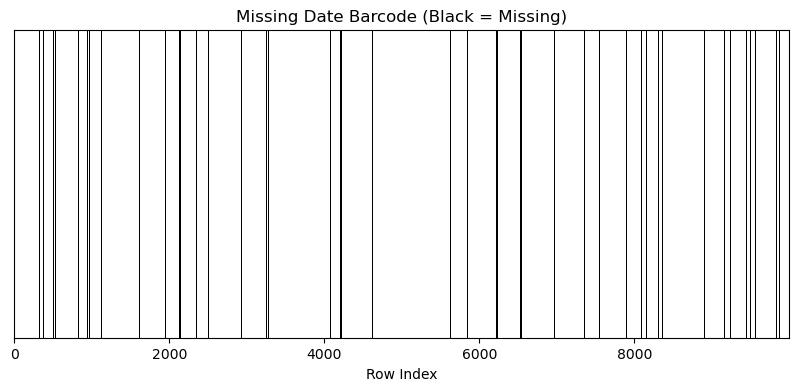

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
# 'imshow' treats the True/False from isnull() as 1/0
plt.imshow(df_cafe[['Transaction Date']].isnull().T, aspect='auto', cmap='binary', interpolation='none')
plt.yticks([]) # Hide the y-axis since it's just one column
plt.xlabel('Row Index')
plt.title('Missing Date Barcode (Black = Missing)')
plt.show()


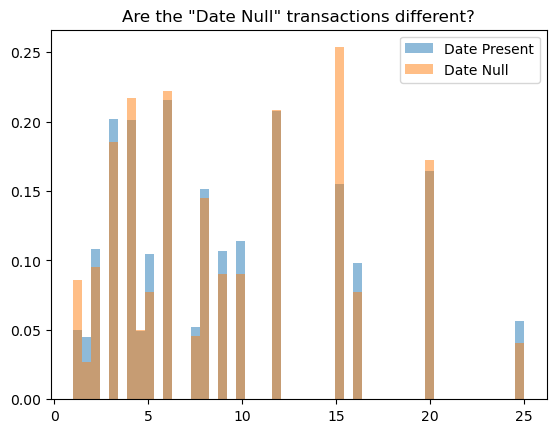

In [52]:
# Split the data
missing = df_cafe[df_cafe['Transaction Date'].isnull()]['Total Spent']
present = df_cafe[df_cafe['Transaction Date'].notnull()]['Total Spent']

plt.hist(present, bins=50, alpha=0.5, label='Date Present', density=True)
plt.hist(missing, bins=50, alpha=0.5, label='Date Null', density=True)
plt.legend()
plt.title('Are the "Date Null" transactions different?')
plt.show()


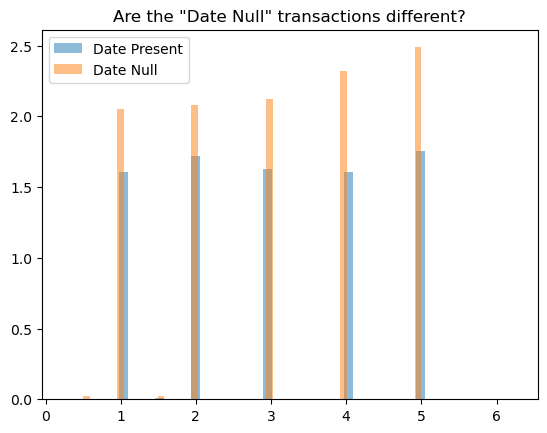

In [53]:
missing = df_cafe[df_cafe['Transaction Date'].isnull()]['Quantity']
present = df_cafe[df_cafe['Transaction Date'].notnull()]['Quantity']

plt.hist(present, bins=50, alpha=0.5, label='Date Present', density=True)
plt.hist(missing, bins=50, alpha=0.5, label='Date Null', density=True)
plt.legend()
plt.title('Are the "Date Null" transactions different?')
plt.show()


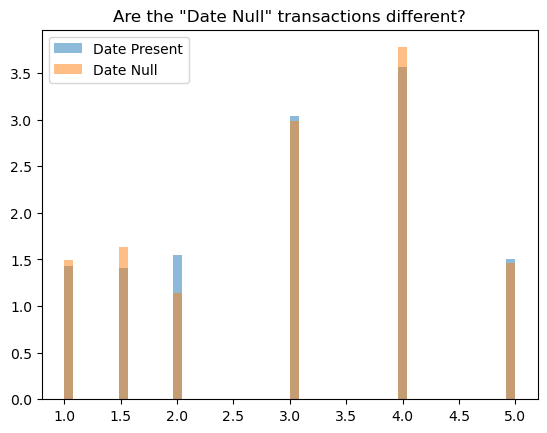

In [54]:
missing = df_cafe[df_cafe['Transaction Date'].isnull()]['Price Per Unit']
present = df_cafe[df_cafe['Transaction Date'].notnull()]['Price Per Unit']

plt.hist(present, bins=50, alpha=0.5, label='Date Present', density=True)
plt.hist(missing, bins=50, alpha=0.5, label='Date Null', density=True)
plt.legend()
plt.title('Are the "Date Null" transactions different?')
plt.show()


Missing data is random.

In [56]:
df_cafe["Transaction Date"].isnull().sum()

460

Deleting the rows with missing date values

In [58]:
df_cafe = df_cafe.dropna(subset=["Transaction Date"])

# Converting Data types

In [60]:
df_cafe = df_cafe.astype({'Transaction ID': str, 'Item': str, 'Payment Method': str, 'Location': str, 
                          'Transaction Date': 'datetime64[ns]'})

In [61]:
df_cafe.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

# Data Validation

Checking whther values in Total Spent follows Quantity*Price Per Unit formluar. 

In [64]:
((df_cafe["Quantity"] * df_cafe["Price Per Unit"]) != df_cafe["Total Spent"]).sum()

360

In [65]:
mask_t = (df_cafe["Quantity"] * df_cafe["Price Per Unit"]) != df_cafe["Total Spent"]

df_cafe.loc[mask_t, "Total Spent"] = df_cafe["Quantity"] * df_cafe["Price Per Unit"]
df_cafe = df_cafe.drop(index="Total Spent", errors="ignore")
df_cafe.tail(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9978,TXN_4302199,Tea,3.0,1.5,4.5,Digital Wallet,Takeaway,2023-02-16
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-store,2023-07-20
9980,TXN_6796890,Tea,4.0,1.5,6.0,Digital Wallet,Takeaway,2023-08-24
9981,TXN_4583012,Sandwich,5.0,4.0,20.0,Digital Wallet,Takeaway,2023-02-27
9982,TXN_8567525,Cookie,2.0,1.0,2.0,Digital Wallet,Takeaway,2023-12-30
9984,TXN_3142496,Smoothie,1.0,4.0,4.0,Cash,Takeaway,2023-07-27
9985,TXN_3297457,Cake,2.0,3.0,6.0,Digital Wallet,Takeaway,2023-01-03
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14
9987,TXN_1784478,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-07-31
9989,TXN_1741685,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-08-18


In [66]:
df_cafe.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [67]:
df_cafe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   object        
 1   Item              9540 non-null   object        
 2   Quantity          9540 non-null   float64       
 3   Price Per Unit    9540 non-null   float64       
 4   Total Spent       9540 non-null   float64       
 5   Payment Method    9540 non-null   object        
 6   Location          9540 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 670.8+ KB


In [68]:
df_cafe.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9540.000000,9540.000000,9540.000000,9540
mean,3.019631,3.005713,9.087317,2023-07-01 23:00:31.698113536
min,0.250000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00
max,6.250000,5.000000,25.000000,2023-12-31 00:00:00
std,1.421103,1.265472,6.030062,NaN


In [69]:
df_cafe["Item"].unique()


array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Sandwich',
       'Juice', 'Tea'], dtype=object)

In [70]:
df_cafe["Quantity"].unique()

array([2.   , 4.   , 5.   , 3.   , 1.   , 1.2  , 1.5  , 0.75 , 1.25 ,
       0.25 , 6.25 , 6.   , 2.25 , 1.875])

In [71]:
df_cafe["Price Per Unit"].unique()

array([2. , 3. , 1. , 5. , 4. , 1.5])

In [72]:
df_cafe["Total Spent"].unique()

array([ 4. , 12. , 10. , 20. ,  9. , 16. , 15. , 25. ,  8. ,  5. ,  3. ,
        6. ,  2. ,  1. ,  7.5,  1.5,  4.5])

In [73]:
df_cafe["Payment Method"].unique()

array(['Credit Card', 'Cash', 'Digital Wallet'], dtype=object)

In [74]:
df_cafe["Location"].unique()

array(['Takeaway', 'In-store'], dtype=object)

In [75]:
df_cafe['Quantity'].describe()
df_cafe['Quantity'].value_counts(dropna = False)

Quantity
5.000    2005
2.000    1971
3.000    1864
4.000    1843
1.000    1837
1.500       7
0.750       3
1.200       2
0.250       2
6.000       2
1.250       1
6.250       1
2.250       1
1.875       1
Name: count, dtype: int64

In [76]:
df_cafe['Price Per Unit'].value_counts(dropna = False)

Price Per Unit
4.0    2725
3.0    2319
2.0    1185
5.0    1150
1.0    1088
1.5    1073
Name: count, dtype: int64

In [77]:
df_cafe['Total Spent'].value_counts(dropna = False)

Total Spent
12.0    986
4.0     966
6.0     940
3.0     879
20.0    830
8.0     768
15.0    671
16.0    518
10.0    493
9.0     471
2.0     462
5.0     451
25.0    244
7.5     224
1.0     223
4.5     217
1.5     197
Name: count, dtype: int64

In [78]:
df_cafe['Payment Method'].value_counts(dropna = False)

Payment Method
Digital Wallet    5212
Credit Card       2170
Cash              2158
Name: count, dtype: int64

In [79]:
df_cafe['Location'].value_counts(dropna = False)

Location
Takeaway    6668
In-store    2872
Name: count, dtype: int64

In [80]:
df_cafe['Transaction Date'].value_counts(dropna = False)

Transaction Date
2023-02-06    40
2023-06-16    40
2023-03-13    39
2023-07-21    39
2023-09-21    39
              ..
2023-04-27    15
2023-11-24    15
2023-03-11    14
2023-02-17    14
2023-07-22    14
Name: count, Length: 365, dtype: int64

In [81]:
df_cafe.reset_index(drop=True, inplace=True)

# Analysing Data

In [83]:
df_cafe.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [84]:
sales = df_cafe.groupby("Item")["Quantity"].sum().sort_values(ascending=False)

In [85]:
sales

Item
Sandwich    6052.500
Coffee      3421.000
Juice       3347.000
Salad       3317.650
Cake        3278.500
Smoothie    3197.000
Tea         3107.125
Cookie      3086.500
Name: Quantity, dtype: float64

<Axes: title={'center': 'Sales per Item'}, xlabel='Item name', ylabel='Quantity sold'>

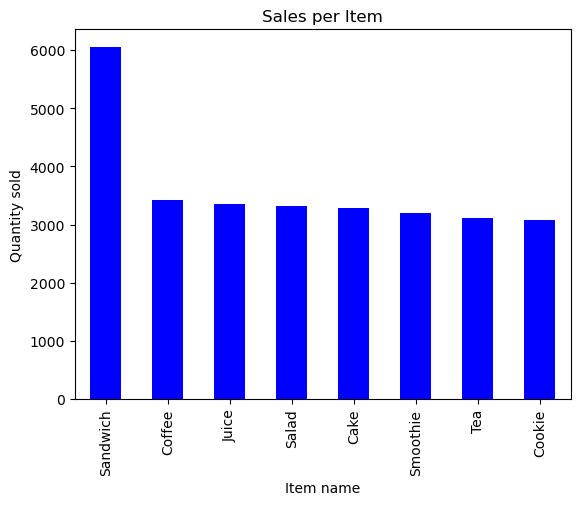

In [86]:
sales.plot(kind = "bar", color = "blue", xlabel = "Item name", ylabel = "Quantity sold",
            title = "Sales per Item")

Sandwich is the most frequently purchased item.

In [88]:
revenue = df_cafe.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

In [89]:
revenue

Item
Sandwich    21419.5
Salad       16404.0
Smoothie    12788.0
Juice       10221.0
Cake         9980.0
Coffee       7136.0
Tea          5143.5
Cookie       3601.0
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Revenue per Item'}, xlabel='Item name', ylabel='Revenue gained'>

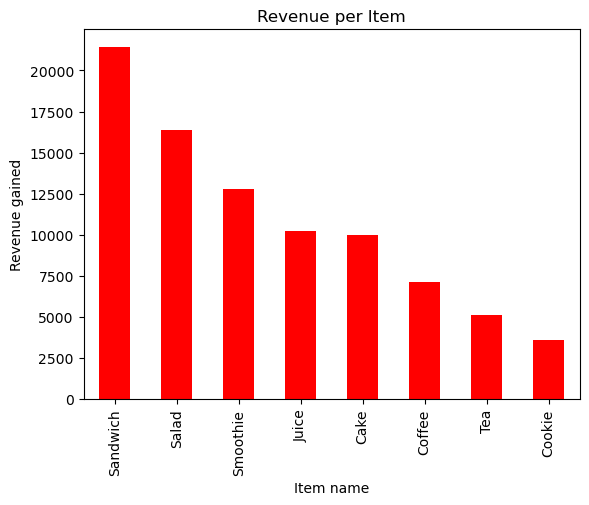

In [90]:
revenue.plot(kind = "bar", color = "red", xlabel = "Item name", ylabel = "Revenue gained",
            title = "Revenue per Item")

Even though Salad is sold less it creates more revenue than Coffee and Juice.

In [92]:
revenue_by_date = df_cafe.groupby("Transaction Date")["Total Spent"].sum()

In [93]:
revenue_by_date

Transaction Date
2023-01-01    176.0
2023-01-02    189.5
2023-01-03    200.0
2023-01-04    269.5
2023-01-05    368.5
              ...  
2023-12-27    228.0
2023-12-28    175.0
2023-12-29    177.5
2023-12-30    210.0
2023-12-31    187.0
Name: Total Spent, Length: 365, dtype: float64

<Axes: title={'center': 'Sales per date'}, xlabel='Date', ylabel='Revenue gained'>

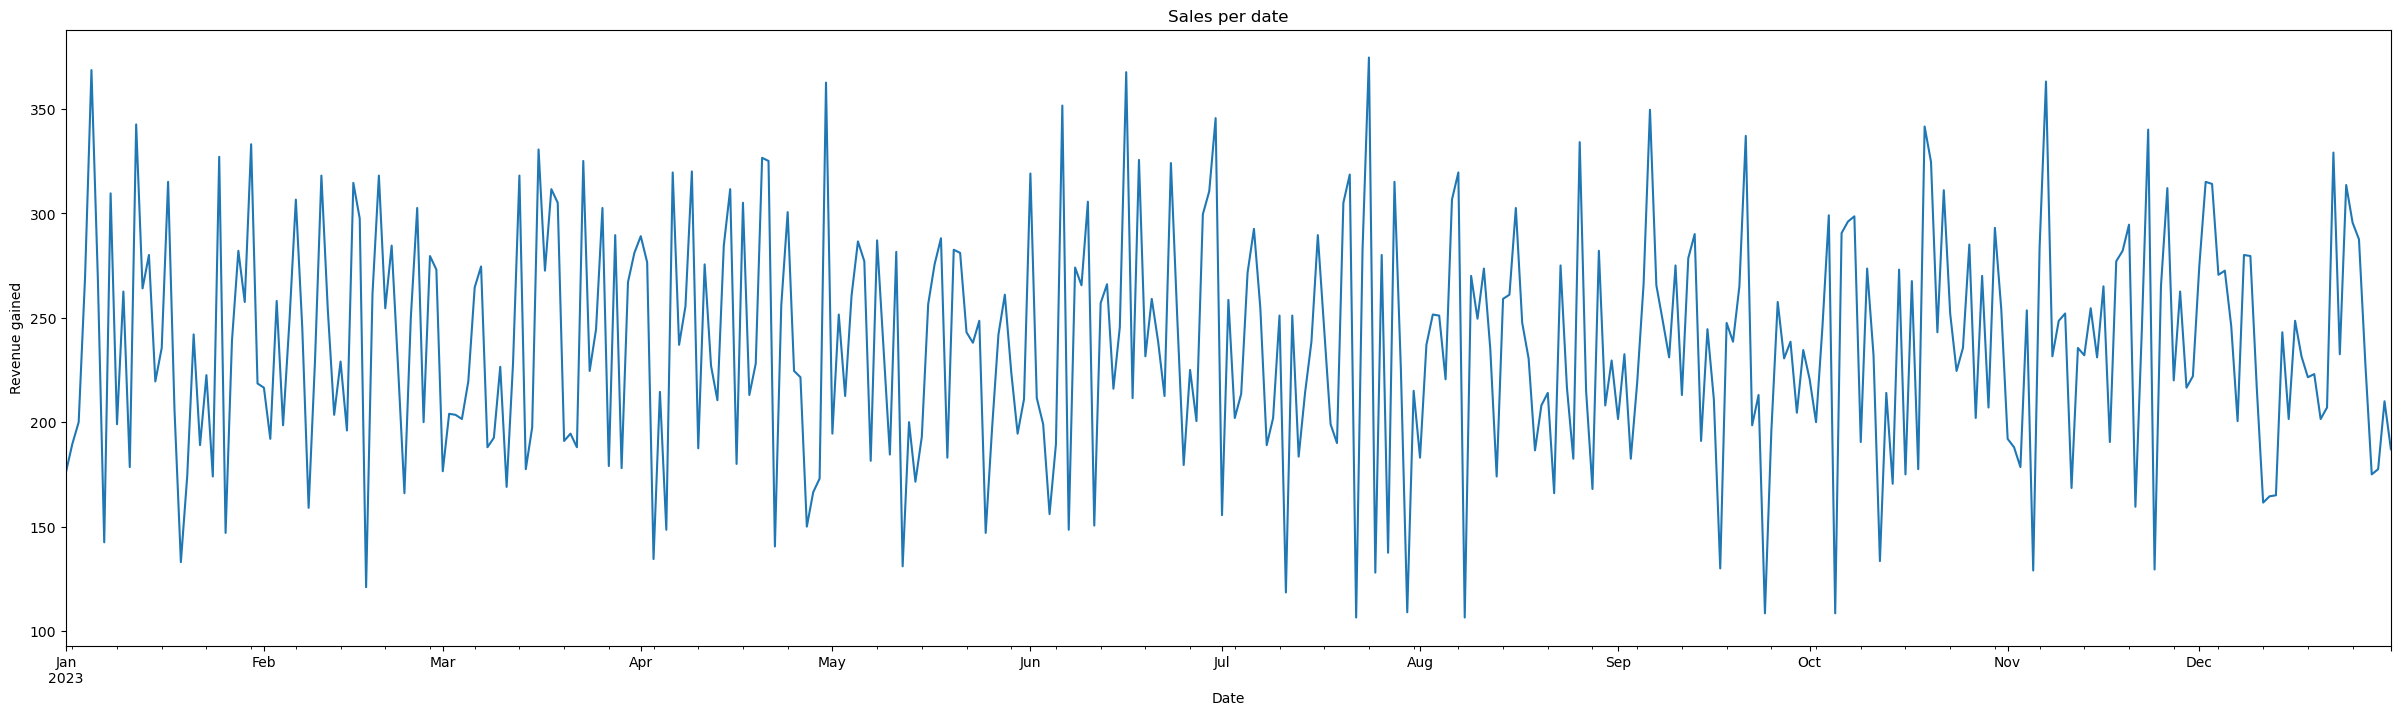

In [94]:
revenue_by_date.plot(kind="line", xlabel="Date", ylabel="Revenue gained", title="Sales per date", 
             figsize=(30, 8))

There are spikes in revenue during January, May, June, August, November. There are also great drops from mid July to begining of August and from end of September to mid Octomber. Overall spikes and drops are consistent.

In [96]:
revenue_by_location = df_cafe.groupby("Location")["Total Spent"].sum().sort_values(ascending=False)

In [97]:
revenue_by_location

Location
Takeaway    60283.0
In-store    26410.0
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Revenue by Location'}, xlabel='Location', ylabel='Revenue gained'>

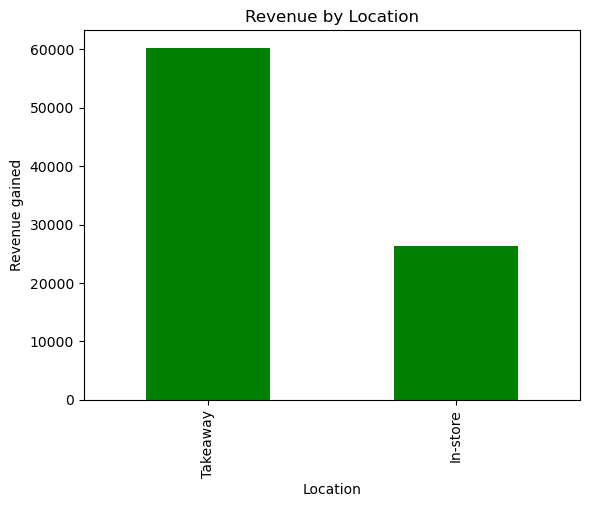

In [98]:
revenue_by_location.plot(kind = "bar", color = "green", xlabel = "Location", ylabel = "Revenue gained",
            title = "Revenue by Location")

Takeaway generate more revenue than in-store purchases

In [100]:
payment = df_cafe["Payment Method"].value_counts()

In [101]:
payment

Payment Method
Digital Wallet    5212
Credit Card       2170
Cash              2158
Name: count, dtype: int64

<Axes: title={'center': 'Payment Method used'}, xlabel='Payment Method', ylabel='usage'>

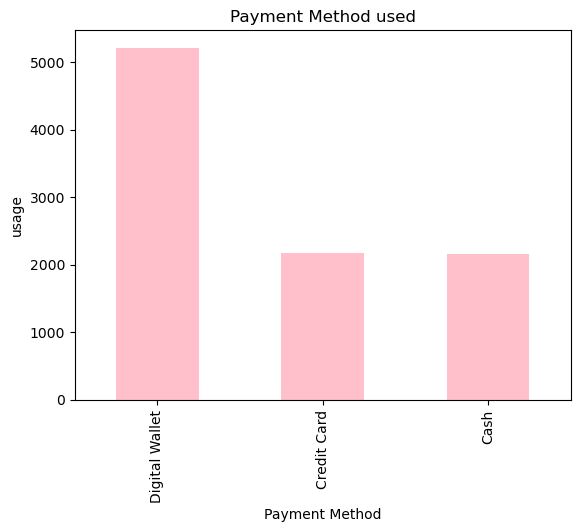

In [102]:
payment.plot(kind = "bar", color = "pink", xlabel = "Payment Method", ylabel = "usage",
            title = "Payment Method used")

Digital Wallet is among the most frequently used methods

In [104]:
revenue_by_payment_method = df_cafe.groupby("Payment Method")["Total Spent"].sum().sort_values(ascending=False)

In [105]:
revenue_by_payment_method

Payment Method
Digital Wallet    46875.0
Cash              19969.0
Credit Card       19849.0
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Revenue in relation to Payment Method'}, xlabel='Payment Method', ylabel='Revenue gained'>

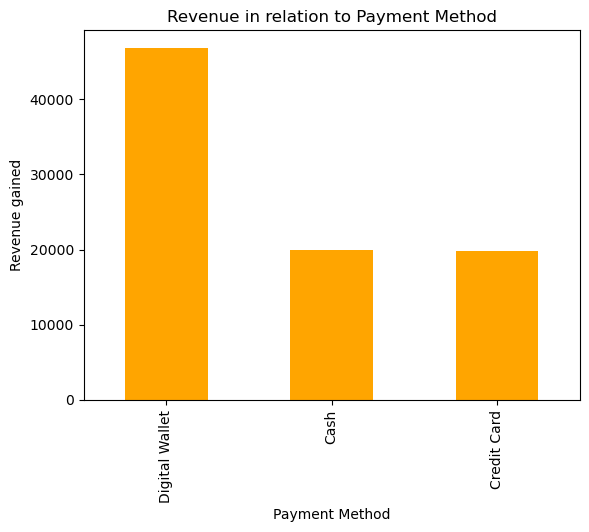

In [106]:
revenue_by_payment_method.plot(kind = "bar", color = "orange", xlabel = "Payment Method", 
                               ylabel = "Revenue gained", title = "Revenue in relation to Payment Method")

Digital Wallet remains the preferred payment method

# Coffee Shop Sales Data Cleaning and Analysis

## Overview
This project focuses on cleaning and analyzing a messy coffee shop transaction dataset. 
The goal was to transform inconsistent raw data into a reliable dataset and get meaningful business insights.

---

## Dataset Description
The dataset contains 10,000 transactions with the following columns:
- Transaction ID
- Item
- Quantity
- Price Per Unit
- Total Spent
- Payment Method
- Location
- Transaction Date

---

## Data Cleaning

### Handling Missing and Inconsistent Values
- Standardized inconsistent missing values (`UNKNOWN`, `ERROR`, `NaN`) for systematic processing
- Converted `Quantity`, `Price Per Unit`, and `Total Spent` to numeric using `pd.to_numeric(errors="coerce")`
- Leveraged relationships between columns:
  - Filled missing `Total Spent` using:  
    **Quantity × Price Per Unit**
  - Filled missing `Quantity` using:  
    **Total Spent ÷ Price Per Unit**
- Estimated missing `Item` and `Price Per Unit` values using item-level consistency
- Imputed missing values in `Payment Method` and `Location` using mode (low percentage of missing data)
- Converted `Transaction Date` to datetime and removed invalid entries
- Removed rows with missing dates (~4.6%) to preserve temporal accuracy

---

## Data Validation
- Verified consistency of calculated fields:
  - Ensured **Total Spent = Quantity × Price Per Unit**
- Checked for:
  - Negative or impossible values
  - Duplicate records
- Confirmed correct data types for all columns
- Reset index after cleaning

---

## Data Analysis

### Objectives
- Identify top-selling products
- Analyze revenue distribution
- Understand customer behavior patterns

---

## Key Insights
- Sandwich is the most sold item by quantity
- Sandwich generates the highest overall revenue
- Sales remain relatively consistent over time
- Takeaway orders contribute the majority of revenue
- Digital Wallet is the most frequently used payment method
- Items, Salad and Smoothie generate higher revenue despite lower sales volume, indicating pricing impact

---

## Conclusion
The dataset was successfully cleaned and validated to ensure reliability. 
The analysis provides insights into product perfomance, sales trends and customer behavioral patterns. This can be used to manage products, optimize sales and improve customer services. 

In [109]:
df_cafe.to_excel('cleaned_cafe_data.xlsx', index=False)
df_cafe.to_csv("cleaned_cafe_data.csv", index=False)